In [1]:
import os

In [2]:
from koopman_gravity import data_loading_pipeline as dlp

In [3]:
FIG_DIR = "figures/trajectory_mapping_game_xy_based_umap_270926"
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
GAME_DATA_PATH = "umap_projections/xy_vase_umap_projection_full.parquet"

In [5]:
trajectory_df, trajectory_edges, trajectory_pairs, Z, Z_prime = dlp(GAME_DATA_PATH, source = "game")

In [6]:
from koopman_gravity import get_umap_bounds

In [7]:
COMBINED_DATA_PATH = "umap_projections/combined_vase_umap_projection.parquet"

In [8]:
umap_bounds = get_umap_bounds(COMBINED_DATA_PATH)

In [9]:
from koopman_gravity import gravity_pipeline

In [10]:
# n_basis sets the size of the fitted RBF basis (15 -> 225 functions); n_eval sets the
# resolution the field is rendered at. They are separate on purpose: a denser basis makes
# the fit degenerate, while a denser evaluation grid costs nothing but a matrix product.
# n_eval must match compute_selection_entropy's n_grid below, since the entropy plots
# compare the two grids cell by cell.
#
# mode=1 selects the slow coordinate (lambda ~ 0.93) rather than mode=0, the invariant
# occupancy density (lambda = 1). The invariant mode is conserved along the dynamics and
# non-negative by Perron-Frobenius, so it describes where vases accumulate rather than
# which direction is preferred. mode=1 is signed, and its zero contour separates the two
# metastable basins of the aesthetic process.
N_EVAL = 30

gravity = gravity_pipeline(
    trajectory_df, trajectory_edges, umap_bounds,
    n_basis=15, n_eval=N_EVAL, mode=1,
)

phi_2D, U, V = gravity["phi_2D"], gravity["U"], gravity["V"]
grid_x, grid_y = gravity["grid_x"], gravity["grid_y"]
centres, sigma = gravity["centres"], gravity["sigma"]

Building Koopman Gram matrices: 100%|██████████| 3/3 [00:00<00:00, 52.48it/s]


Koopman operator: 225 basis functions, spectral radius 1.0000
Koopman mode 1: λ = 0.93377 (slow coordinate), relaxation ≈ 15.1 generations
Orientation check — winner has higher Φ in 59.6% of 68,100 matchups (chance = 50%)
Flipping gravity orientation.


In [11]:
from koopman_gravity import validate_gravity_holdout

# Does the field predict the choices of people it never saw? Folds split on
# participant_id, since matchups within a session share champions and would leak.
holdout = validate_gravity_holdout(trajectory_df, umap_bounds, n_basis=15, mode=1, n_folds=5)
holdout

Building Koopman Gram matrices: 100%|██████████| 2/2 [00:00<00:00, 37.04it/s]


Orientation check — winner has higher Φ in 59.7% of 54,475 matchups (chance = 50%)
Flipping gravity orientation.
  fold 0: train 0.5969 (54,475)  |  test 0.5940 (13,625)


Building Koopman Gram matrices: 100%|██████████| 2/2 [00:00<00:00, 50.09it/s]


Orientation check — winner has higher Φ in 59.7% of 54,475 matchups (chance = 50%)
Flipping gravity orientation.
  fold 1: train 0.5971 (54,475)  |  test 0.5954 (13,625)


Building Koopman Gram matrices: 100%|██████████| 2/2 [00:00<00:00, 50.45it/s]


Orientation check — winner has higher Φ in 59.4% of 54,475 matchups (chance = 50%)
Flipping gravity orientation.
  fold 2: train 0.5942 (54,475)  |  test 0.5985 (13,625)


Building Koopman Gram matrices: 100%|██████████| 2/2 [00:00<00:00, 50.91it/s]


Orientation check — winner has higher Φ in 59.8% of 54,475 matchups (chance = 50%)
Keeping original orientation.
  fold 3: train 0.5981 (54,475)  |  test 0.5944 (13,625)


Building Koopman Gram matrices: 100%|██████████| 2/2 [00:00<00:00, 49.63it/s]


Orientation check — winner has higher Φ in 59.7% of 54,500 matchups (chance = 50%)
Keeping original orientation.
  fold 4: train 0.5971 (54,500)  |  test 0.5976 (13,600)

Held-out matchup accuracy: 0.5960 (chance = 0.5) across 5 participant folds


,fold,n_train_matchups,train_win_rate,n_test_matchups,test_win_rate
0,0,54475.0,0.596934,13625.0,0.593982
1,1,54475.0,0.597118,13625.0,0.595376
2,2,54475.0,0.594218,13625.0,0.598532
3,3,54475.0,0.598054,13625.0,0.594422
4,4,54500.0,0.597083,13600.0,0.597574
5,mean,54480.0,0.596681,13620.0,0.595977


In [12]:
from koopman_gravity import compute_selection_entropy

In [13]:
entropy_grid, count_grid, x_edges, y_edges = compute_selection_entropy(
    trajectory_pairs, trajectory_df, umap_bounds, n_grid=N_EVAL
)

Cells with ≥5 selected transitions: 411 / 900
Entropy range: 0.333 – 0.991


In [14]:
from koopman_gravity import plot_gravity_field, plot_selection_entropy, plot_entropy_vs_gravity

In [15]:
# grid_x / grid_y come from gravity_pipeline (the evaluation grid). Previously they were
# reshaped out of `centres`, which only worked while the basis and the output grid were
# forced to be the same lattice.
print(f"evaluation grid: {grid_x.shape}   RBF basis: {centres.shape[0]} functions")

evaluation grid: (30, 30)   RBF basis: 225 functions


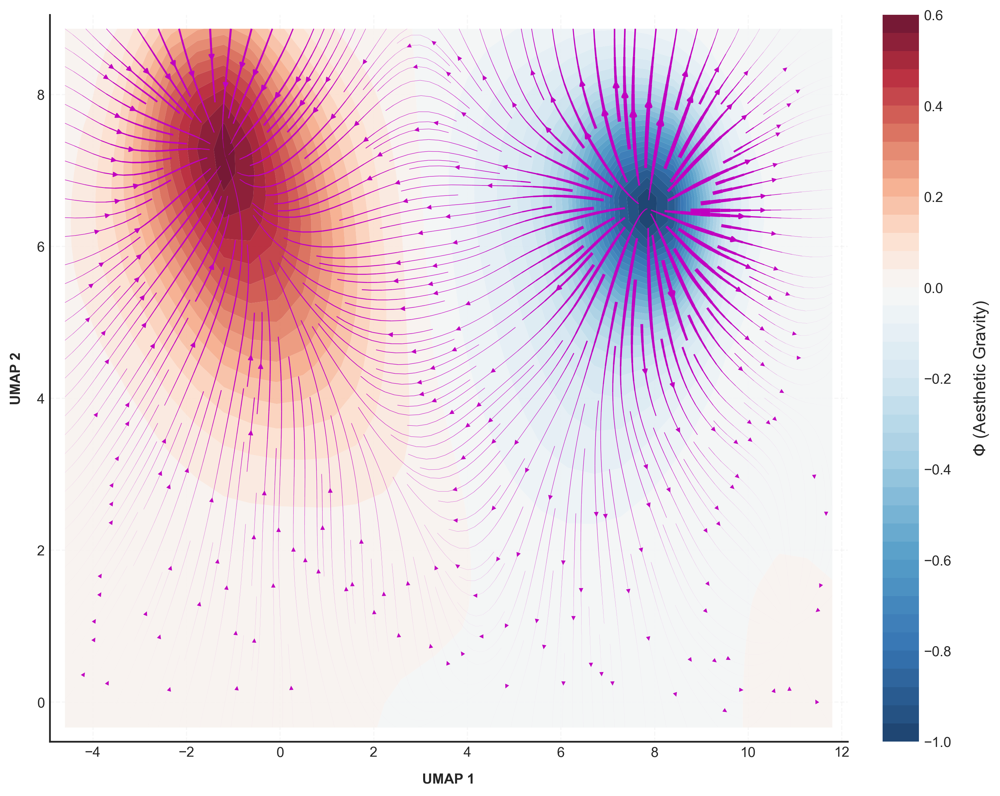

In [16]:
plot_gravity_field(
    grid_x, grid_y, phi_2D, U, V,
    umap_bounds["xlim"], umap_bounds["ylim"],
    title=None,
    save_path=os.path.join(FIG_DIR, "gravity_field.png"),
)

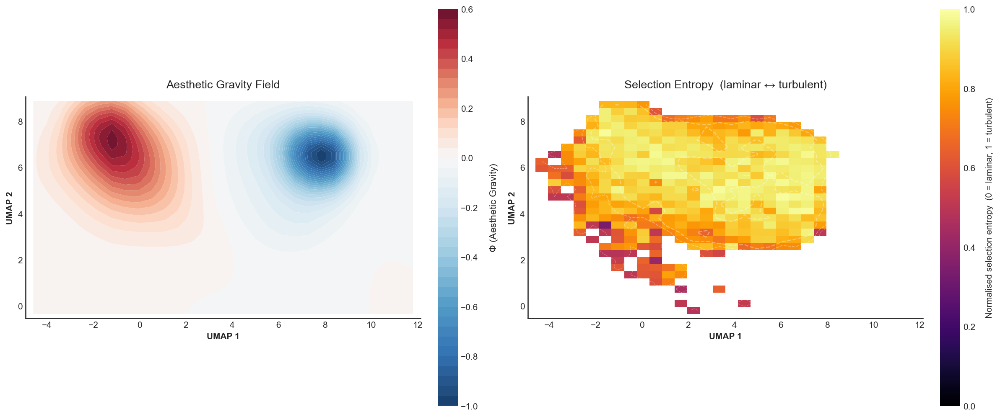

In [17]:
plot_selection_entropy(
    grid_x, grid_y, phi_2D,
    entropy_grid, count_grid, x_edges, y_edges,
    umap_bounds["xlim"], umap_bounds["ylim"],
    save_path=os.path.join(FIG_DIR, "gravity_vs_entropy.png"),
)

Non-normal distribution detected (Shapiro-Wilk p < 0.05) — Spearman preferred.
Gravity φ vs selection entropy  (n=411 cells)
  Pearson  r = -0.0666  |  Spearman ρ = -0.0984


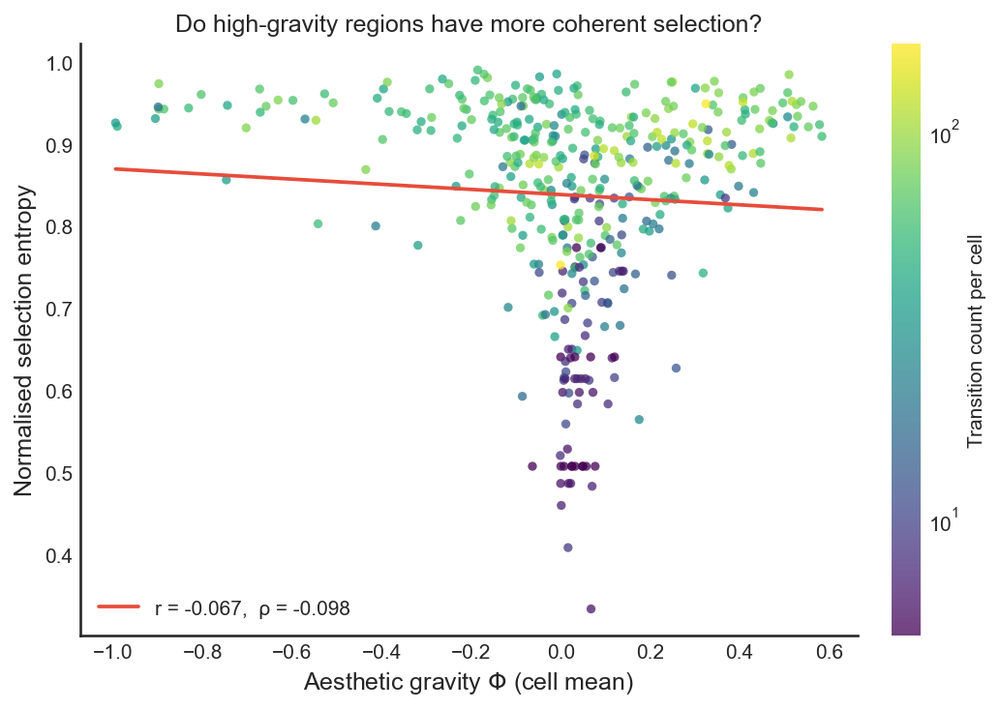

In [18]:
plot_entropy_vs_gravity(
    phi_2D, entropy_grid, count_grid,
    save_path=os.path.join(FIG_DIR, "entropy_vs_gravity_scatter.png"),
)

In [19]:
from koopman_gravity import compute_gravity_scores, plot_vase_grid
import numpy as np

# Score every vase by evaluating the oriented eigenfunction at its exact UMAP position.
# gravity_pipeline now returns the eigenvector, so this is exact -- it replaces the old
# workaround of interpolating the coarse phi_2D grid with RegularGridInterpolator.
vase_meta = (
    trajectory_df[["vase_id", "umap_x", "umap_y"]]
    .drop_duplicates("vase_id")
    .reset_index(drop=True)
    .copy()
)
vase_meta["aesthetic_gravity"] = compute_gravity_scores(
    np.vstack([vase_meta["umap_x"].to_numpy(), vase_meta["umap_y"].to_numpy()]),
    gravity["eigenvector"], centres, sigma,
)
print(f"vase_meta: {len(vase_meta):,} unique vases")

vase_meta: 81,720 unique vases


In [20]:
import pandas as pd

# Load XY contour points and reconstruct the vase_id key (participant_id::generation_key::vase)
# to match trajectory_df. Only load the 5 columns needed; filter to game vases only.
xy_raw = pd.read_parquet(
    "../file_processing/processed/xy_data.parquet",
    columns=["participant_id", "generation_key", "vase", "x", "y"],
)
xy_raw["vase_id"] = xy_raw["participant_id"] + "::" + xy_raw["generation_key"] + "::" + xy_raw["vase"]

valid_ids = set(vase_meta["vase_id"])
game_xy_df = (
    xy_raw[xy_raw["vase_id"].isin(valid_ids)][["vase_id", "x", "y"]]
    .reset_index(drop=True)
)
del xy_raw
print(f"game_xy_df: {game_xy_df['vase_id'].nunique():,} vase contours, {len(game_xy_df):,} rows")

game_xy_df: 81,720 vase contours, 20,430,000 rows


In [21]:
plot_vase_grid(
    game_xy_df, vase_meta, umap_bounds,
    n_grid=100,
    save_path=os.path.join(FIG_DIR, "vase_gravity_grid.png"),
)

In [22]:
from koopman_gravity import plot_vase_silhouette, score_real_vases

# Score all real museum vases against the gravity field, again exactly rather than by
# interpolating the grid.
real_umap = (
    pd.read_parquet(
        "umap_projections/real_vase_umap_projection.parquet",
        columns=["vase_id", "umap_x", "umap_y"],
    )
    .drop_duplicates("vase_id")
    .reset_index(drop=True)
)
real_umap = score_real_vases(real_umap, gravity["eigenvector"], centres, sigma)

best_row = real_umap.loc[real_umap["aesthetic_gravity"].idxmax()]
print(f"Most beautiful: {best_row['vase_id']}  (phi = {best_row['aesthetic_gravity']:.4f})")
print(f"UMAP position:  ({best_row['umap_x']:.3f}, {best_row['umap_y']:.3f})")
print(f"Gravity range:  {real_umap['aesthetic_gravity'].min():.4f} - {real_umap['aesthetic_gravity'].max():.4f}")

Most beautiful: tp_43043_0  (phi = 0.5842)
UMAP position:  (-1.070, 7.153)
Gravity range:  -0.9464 - 0.5842


Contour points loaded: 250


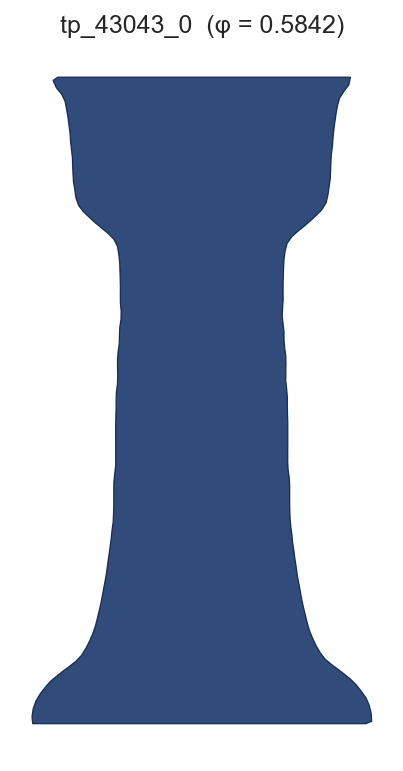

In [23]:
# Load only the winning vase's contour via predicate pushdown (avoids reading all 26M rows)
best_contour = (
    pd.read_parquet(
        "../real_vase_data/all_profiles_120526.parquet",
        filters=[("gpp_no", "==", best_row["vase_id"])],
    )
    .sort_values("point_order")
    .rename(columns={"gpp_no": "vase_id"})
)
print(f"Contour points loaded: {len(best_contour)}")

plot_vase_silhouette(
    best_contour,
    title=f"{best_row['vase_id']}  (φ = {best_row['aesthetic_gravity']:.4f})",
    save_path=os.path.join(FIG_DIR, f"most_beautiful_{best_row['vase_id']}.png"),
)

## Multi-mode basin decomposition

The gravity field above uses one eigenfunction, which can only express a *bipartition* —
one positive pole, one negative pole, and the bottleneck between them. Several attractors
therefore cannot appear in it, however many the data holds.

To recover them, several slow eigenfunctions are used jointly as coordinates and vases are
clustered in that space: k eigenfunctions resolve up to k+1 metastable basins. Modes 1-3
are used here (lambda = 0.934, 0.855, 0.843). Modes 2 and 3 are nearly degenerate, so they
are taken together rather than split.

Note that the many attractors visible in earlier versions of the gravity map were not
reproducible — perturbing the input coordinates by 1 part in 1e12 changed their count from
20 to 17 — so they were numerical artefacts of the unregularised operator, not basins.

In [24]:
from koopman_gravity import decompose_basins, plot_basin_map, plot_basin_representatives

basins = decompose_basins(
    trajectory_df, trajectory_edges, umap_bounds,
    n_basis=15, modes=(1, 2, 3), n_basins=4,
)
basins["summary"]

Building Koopman Gram matrices: 100%|██████████| 3/3 [00:00<00:00, 51.83it/s]

Koopman operator: 225 basis functions, spectral radius 1.0000
Using 3 slow modes to resolve up to 4 basins:
  mode 1: λ = 0.93377, relaxation ≈ 15.1 generations
  mode 2: λ = 0.85506, relaxation ≈ 6.9 generations
  mode 3: λ = 0.84304, relaxation ≈ 6.4 generations



basin occupancy: [31629, 30499, 11802, 7790]
basin self-retention (diagonal): [0.828, 0.711, 0.782, 0.682]


,basin,n_vases,umap_x,umap_y,representative_vase_id,cross_basin_matchups,win_rate
0,0,31629,2.288398,4.208524,122acc4b-923f-47c5-923a-b9ae0bf9a715::round_1_...,14727,0.570313
1,1,30499,4.388022,5.714526,7f0ac6cf-0059-41bd-80a8-5b7acce26b5a::round_2_...,16966,0.412354
2,2,11802,-0.891396,7.498036,ec9b9c63-2a1a-4ca7-9fce-3932a5a8bf1d::round_3_...,7431,0.646616
3,3,7790,6.956576,6.421518,b39ff714-5444-4480-9c9b-457a8092a7fc::round_3_...,5444,0.382807


In [25]:
# Self-retention on the diagonal: how often a lineage entering a basin stays there.
# A strongly diagonal matrix means the partition sits at genuine bottlenecks.
basins["transitions"].round(3)

to_basin,0,1,2,3
from_basin,,,,
0,0.828,0.095,0.075,0.002
1,0.156,0.711,0.083,0.050
2,0.129,0.087,0.782,0.002
3,0.021,0.286,0.010,0.682


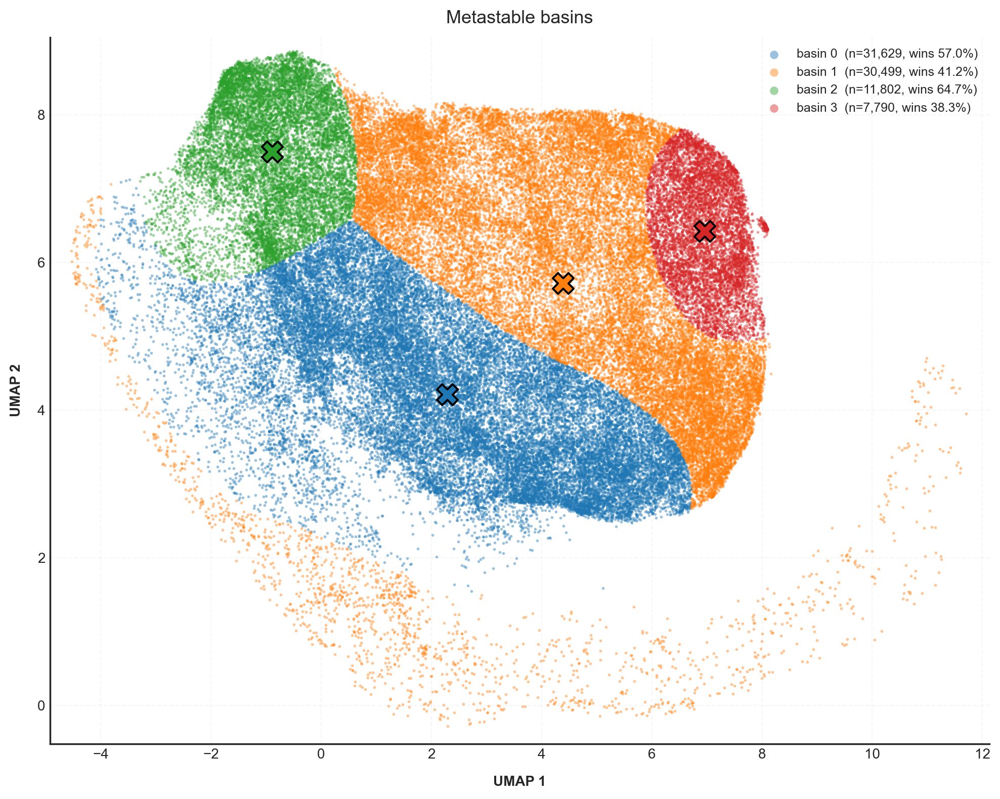

In [26]:
plot_basin_map(
    basins["embedding"], basins["basins"], umap_bounds,
    summary=basins["summary"],
    save_path=os.path.join(FIG_DIR, "basin_map.png"),
)

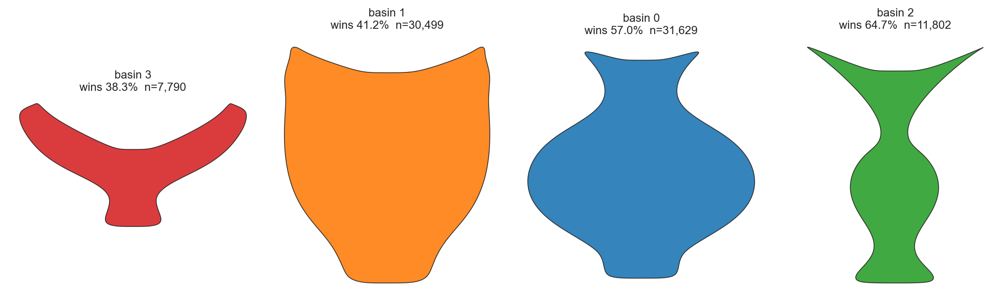

In [27]:
# One representative vase per basin, ordered left-to-right from least to most preferred
# by head-to-head win rate.
plot_basin_representatives(
    game_xy_df, basins["summary"],
    save_path=os.path.join(FIG_DIR, "basin_representatives.png"),
)